# Phase 3

This notebook maps the image-token math behind the earlier runs using the current OpenAI docs:

- Vision guide: https://developers.openai.com/api/docs/guides/images-vision
- Pricing page: https://openai.com/api/pricing/

For `GPT-4o`, `GPT-4.1`, and `GPT-4o-mini`, the docs say:

- `detail="low"` is a fixed base token cost
- `detail="high"` uses 2048px bounding, then rescales so the shortest side is 768px, then counts 512px tiles

I used those rules directly below.


In [1]:
from pathlib import Path
import base64
import json
import math

from dotenv import load_dotenv
from openai import OpenAI
from PIL import Image, ImageDraw, ImageOps
from IPython.display import display, Markdown

load_dotenv(Path(".env"))
client = OpenAI()


def encode_image_to_base64(image_path: Path) -> str:
    return base64.b64encode(image_path.read_bytes()).decode("utf-8")


def image_to_data_url(image_path: Path) -> str:
    suffix = image_path.suffix.lower().lstrip(".")
    mime = "jpeg" if suffix in {"jpg", "jpeg"} else suffix
    return f"data:image/{mime};base64,{encode_image_to_base64(image_path)}"


def clean_json_text(text: str) -> str:
    cleaned = text.strip()
    if cleaned.startswith("```"):
        cleaned = cleaned.split("\n", 1)[1]
        if cleaned.endswith("```"):
            cleaned = cleaned[:-3]
    return cleaned.strip()


def parse_json_response(text: str):
    return json.loads(clean_json_text(text))


def usage_to_dict(usage):
    return {
        "input_tokens": usage.input_tokens,
        "output_tokens": usage.output_tokens,
        "total_tokens": usage.total_tokens,
    }


In [2]:
MODEL_RULES = {
    "gpt-4o": {"base_tokens": 85, "tile_tokens": 170, "input_per_million": 2.50},
    "gpt-4o-mini": {"base_tokens": 2833, "tile_tokens": 5667, "input_per_million": 0.15},
}


def calculate_image_tokens(width: int, height: int, model: str, detail: str) -> dict:
    rules = MODEL_RULES[model]
    if detail == "low":
        tokens = rules["base_tokens"]
        return {
            "model": model,
            "detail": detail,
            "original_size": (width, height),
            "resized_size": (512, 512),
            "tiles": 0,
            "image_tokens": tokens,
            "estimated_input_cost_usd": round(tokens / 1_000_000 * rules["input_per_million"], 6),
        }

    scale_1 = min(1.0, 2048 / max(width, height))
    w1 = width * scale_1
    h1 = height * scale_1

    scale_2 = 768 / min(w1, h1)
    w2 = w1 * scale_2
    h2 = h1 * scale_2

    tiles_w = math.ceil(w2 / 512)
    tiles_h = math.ceil(h2 / 512)
    tiles = tiles_w * tiles_h
    tokens = rules["base_tokens"] + tiles * rules["tile_tokens"]

    return {
        "model": model,
        "detail": detail,
        "original_size": (width, height),
        "resized_size": (round(w2), round(h2)),
        "tiles": tiles,
        "image_tokens": tokens,
        "estimated_input_cost_usd": round(tokens / 1_000_000 * rules["input_per_million"], 6),
    }


In [3]:
size_matrix = {
    "thumbnail_320x180": (320, 180),
    "1080p_1920x1080": (1920, 1080),
    "4k_3840x2160": (3840, 2160),
    "large_4000x3000": (4000, 3000),
}

matrix_results = []
for label, (width, height) in size_matrix.items():
    for model in MODEL_RULES:
        for detail in ["low", "high"]:
            row = {"label": label}
            row.update(calculate_image_tokens(width, height, model, detail))
            matrix_results.append(row)

print(json.dumps(matrix_results, indent=2))


[
  {
    "label": "thumbnail_320x180",
    "model": "gpt-4o",
    "detail": "low",
    "original_size": [
      320,
      180
    ],
    "resized_size": [
      512,
      512
    ],
    "tiles": 0,
    "image_tokens": 85,
    "estimated_input_cost_usd": 0.000213
  },
  {
    "label": "thumbnail_320x180",
    "model": "gpt-4o",
    "detail": "high",
    "original_size": [
      320,
      180
    ],
    "resized_size": [
      1365,
      768
    ],
    "tiles": 6,
    "image_tokens": 1105,
    "estimated_input_cost_usd": 0.002763
  },
  {
    "label": "thumbnail_320x180",
    "model": "gpt-4o-mini",
    "detail": "low",
    "original_size": [
      320,
      180
    ],
    "resized_size": [
      512,
      512
    ],
    "tiles": 0,
    "image_tokens": 2833,
    "estimated_input_cost_usd": 0.000425
  },
  {
    "label": "thumbnail_320x180",
    "model": "gpt-4o-mini",
    "detail": "high",
    "original_size": [
      320,
      180
    ],
    "resized_size": [
      1365,
      7

In [4]:
walkthrough = calculate_image_tokens(4000, 3000, "gpt-4o", "high")
print("4000x3000 on gpt-4o with detail=high")
print(json.dumps(walkthrough, indent=2))

print()
print("How it happens:")
print("1. Fit inside 2048x2048 -> 2048x1536")
print("2. Rescale shortest side to 768 -> 1024x768")
print("3. Tile count -> ceil(1024/512) * ceil(768/512) = 2 * 2 = 4")
print("4. Token total -> 85 + 4 * 170 = 765")


4000x3000 on gpt-4o with detail=high
{
  "model": "gpt-4o",
  "detail": "high",
  "original_size": [
    4000,
    3000
  ],
  "resized_size": [
    1024,
    768
  ],
  "tiles": 4,
  "image_tokens": 765,
  "estimated_input_cost_usd": 0.001912
}

How it happens:
1. Fit inside 2048x2048 -> 2048x1536
2. Rescale shortest side to 768 -> 1024x768
3. Tile count -> ceil(1024/512) * ceil(768/512) = 2 * 2 = 4
4. Token total -> 85 + 4 * 170 = 765


{'clean_table': (1024, 1536), 'padded': (1024, 2336), 'cropped': (1024, 1536)}


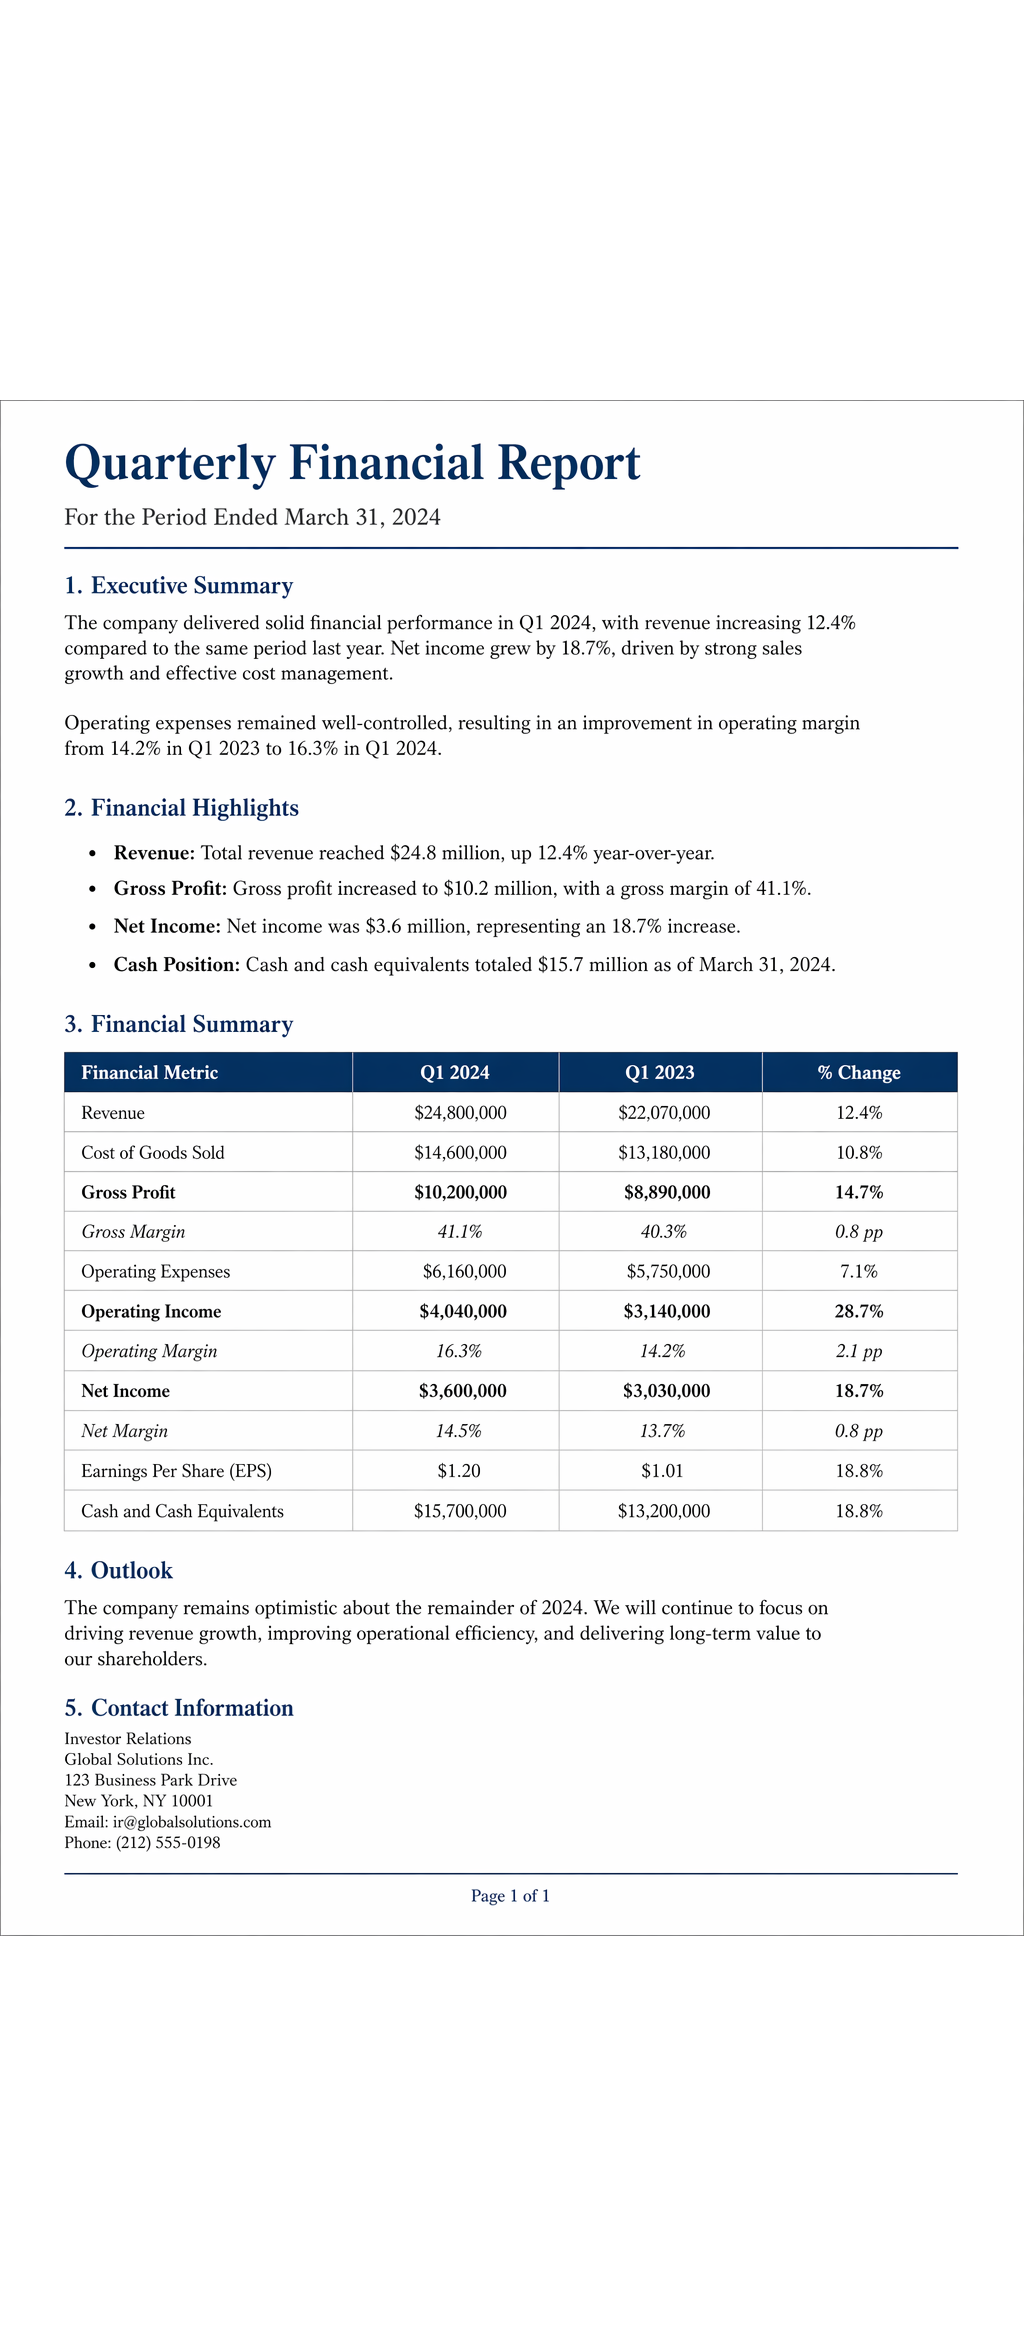

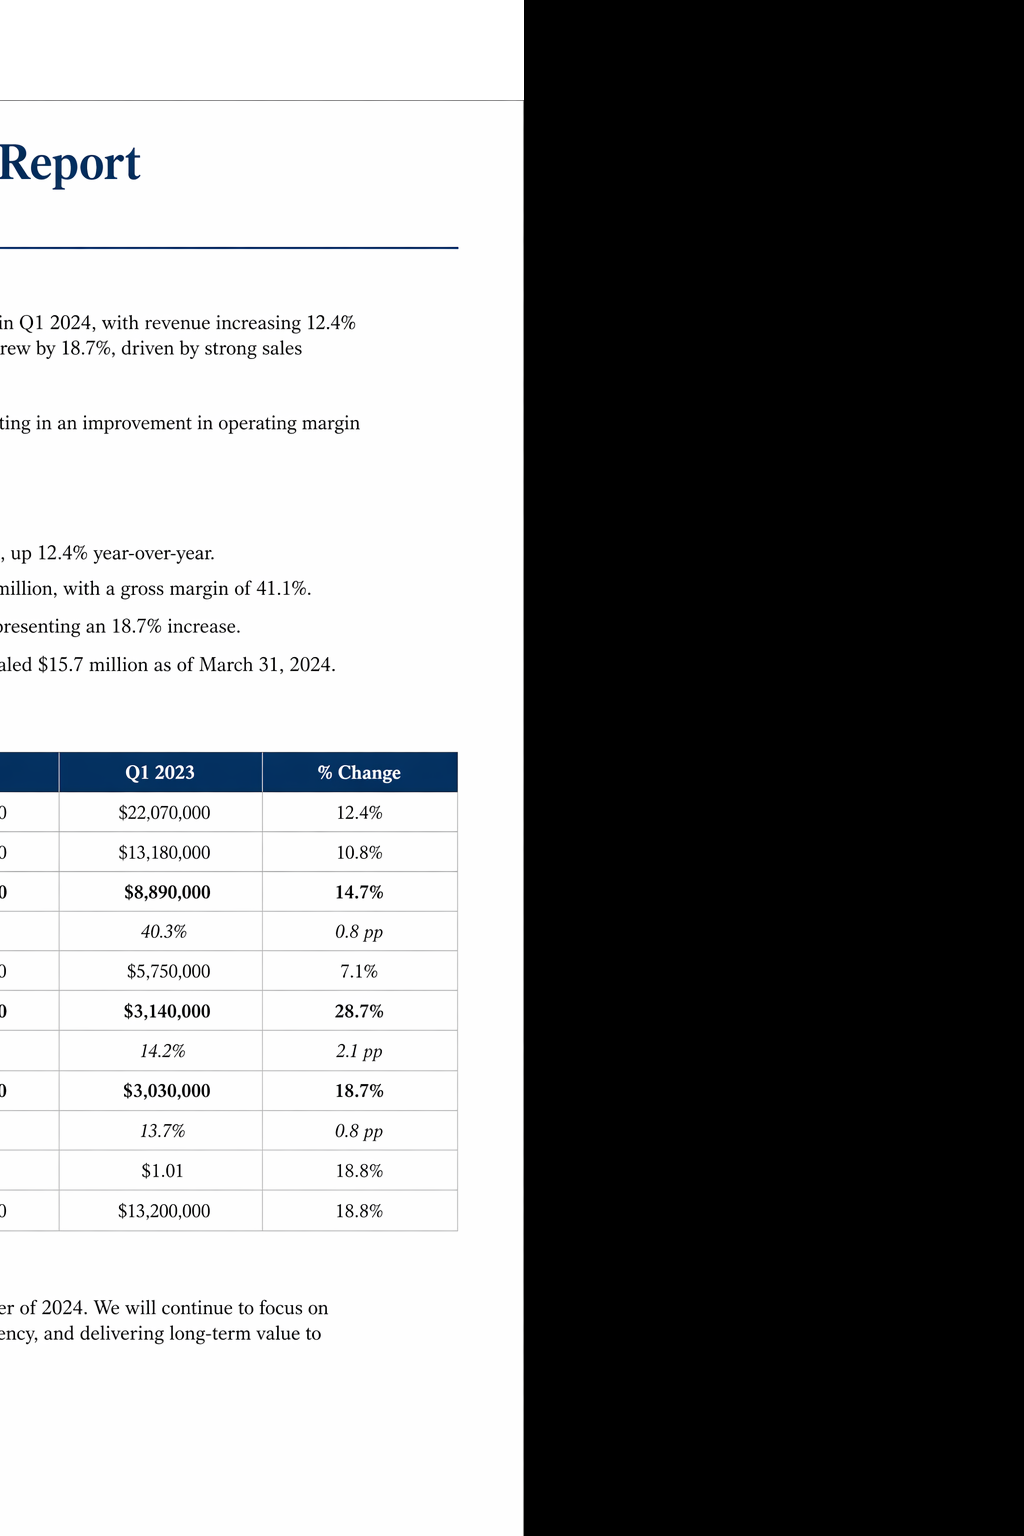

gpt-4o high before crop: {'model': 'gpt-4o', 'detail': 'high', 'original_size': (1024, 2336), 'resized_size': (768, 1752), 'tiles': 8, 'image_tokens': 1445, 'estimated_input_cost_usd': 0.003613}
gpt-4o high after crop: {'model': 'gpt-4o', 'detail': 'high', 'original_size': (1024, 1536), 'resized_size': (768, 1152), 'tiles': 6, 'image_tokens': 1105, 'estimated_input_cost_usd': 0.002763}
gpt-4o-mini high before crop: {'model': 'gpt-4o-mini', 'detail': 'high', 'original_size': (1024, 2336), 'resized_size': (768, 1752), 'tiles': 8, 'image_tokens': 48169, 'estimated_input_cost_usd': 0.007225}
gpt-4o-mini high after crop: {'model': 'gpt-4o-mini', 'detail': 'high', 'original_size': (1024, 1536), 'resized_size': (768, 1152), 'tiles': 6, 'image_tokens': 36835, 'estimated_input_cost_usd': 0.005525}


In [5]:
clean_table = Image.open(Path("images/clean_table.png")).convert("RGB")
padded = ImageOps.expand(clean_table, border=(0, 400, 0, 400), fill="white")
padded_path = Path("images/clean_table_padded_demo.png")
padded.save(padded_path)

cropped = padded.crop((500, 300, 500 + clean_table.width, 300 + clean_table.height))

print({"clean_table": clean_table.size, "padded": padded.size, "cropped": cropped.size})
display(padded)
display(cropped)

before = calculate_image_tokens(*padded.size, "gpt-4o", "high")
after = calculate_image_tokens(*cropped.size, "gpt-4o", "high")
mini_before = calculate_image_tokens(*padded.size, "gpt-4o-mini", "high")
mini_after = calculate_image_tokens(*cropped.size, "gpt-4o-mini", "high")

print("gpt-4o high before crop:", before)
print("gpt-4o high after crop:", after)
print("gpt-4o-mini high before crop:", mini_before)
print("gpt-4o-mini high after crop:", mini_after)


## Answers

**How are tokens calculated for a large image like `4000x3000`?**

Using the current OpenAI docs for `gpt-4o` style tile models:

1. Fit the image inside a `2048x2048` box while keeping aspect ratio.
2. Rescale so the shortest side becomes `768`.
3. Count `512x512` tiles.
4. Add the base tokens.

For `4000x3000`, that turns into `2048x1536`, then `1024x768`, which is `4` tiles total. On `gpt-4o`, the final image token cost is `85 + 4*170 = 765`.

**How is the image resized before tiling?**

The docs use a two-step resize for these older vision-capable families. First there is a max-dimension clamp to `2048`. After that, high detail snaps the shortest side to `768`, and only then does tiling happen. That is why a `1080p` image and a `4K` image with the same aspect ratio can end up costing the same number of image tokens in `detail="high"`.

**What preprocessing steps can reduce unnecessary token usage?**

Cropping blank borders is the easiest win. The padded table demo shows that whitespace can increase tile count even when it adds no value. Other cheap wins:

- Crop margins, scanner beds, and letterboxing
- Split a packet into pages instead of stitching everything into one giant image
- Use `detail="low"` for coarse routing or classification
- Only send high detail on pages that actually contain small text, tables, or handwriting

One surprise from the docs: high detail on `gpt-4o-mini` is not automatically cheap. The image token rates are much higher than `gpt-4o`, so a mini model with high-detail vision can land in the same cost ballpark as a stronger model with low detail.
